# Experiment result analysis

This notebook compares the published batch and online-learning experiment outputs. Run it from the repository root after installing `requirements.txt`. It reads the versioned result files in `Testing/`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

In [2]:
with open('Testing/Results_96.pkl', 'rb') as f:
    results_96 = pickle.load(f)

with open('Testing/Results_1_3_5.pkl', 'rb') as f:
    results_1_2_5 = pickle.load(f)

with open('Testing/batch_output_96.pkl', 'rb') as f:
    batch_output = pickle.load(f)

In [3]:
results_1_2_5, predictions_1_2_5 = results_1_2_5
results_96, predictions_96 = results_96

In [4]:
predictions_1_2_5 = pd.DataFrame(predictions_1_2_5).T
predictions_96 = pd.DataFrame(predictions_96).T

predictions_1_2_5.index = pd.Index(range(1,21), name = "Storm Number")
predictions_96.index = pd.Index(range(1,21), name = "Storm Number")
batch_output.index = pd.Index(range(1,21), name = "Storm Number")

In [5]:
batch_output

,y_true,y_pred
Storm Number,,
1,"[-20.0, -16.0, -15.0, -17.0, -15.0, -18.0, -18...","[-68.52956, -67.53423, -67.62473, -67.50075, -..."
2,"[18.0, 15.0, 15.0, 14.0, 14.0, 13.0, 14.0, 15....","[-36.471947, -36.37764, -36.42968, -36.445446,..."
3,"[-32.0, -30.0, -23.0, -28.0, -27.0, -28.0, -28...","[-53.07134, -51.230244, -50.056087, -49.131584..."
4,"[7.0, 7.0, 6.0, 6.0, 6.0, 6.0, 7.0, 7.0, 5.0, ...","[-34.862484, -34.969208, -34.97636, -34.917633..."
5,"[-77.0, -70.0, -66.0, -76.0, -83.0, -66.0, -56...","[-41.400093, -42.51442, -41.872, -39.978493, -..."
6,"[-29.0, -20.0, -12.0, -14.0, -20.0, -19.0, -23...","[-64.90256, -67.87206, -67.81633, -64.82938, -..."
7,"[-58.0, -63.0, -63.0, -58.0, -48.0, -50.0, -43...","[-34.93762, -35.41223, -34.98561, -35.17229, -..."
8,"[-55.0, -52.0, -50.0, -46.0, -43.0, -42.0, -38...","[-61.364872, -60.316566, -58.856785, -57.69931..."
9,"[-234.0, -215.0, -181.0, -168.0, -160.0, -149....","[-310.5471, -274.66968, -238.38219, -209.25966..."


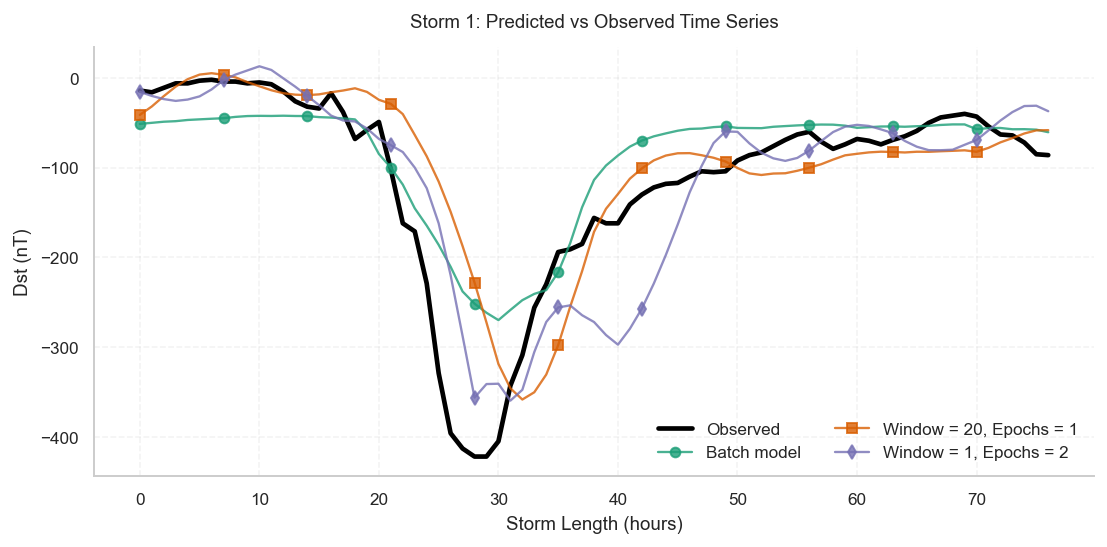

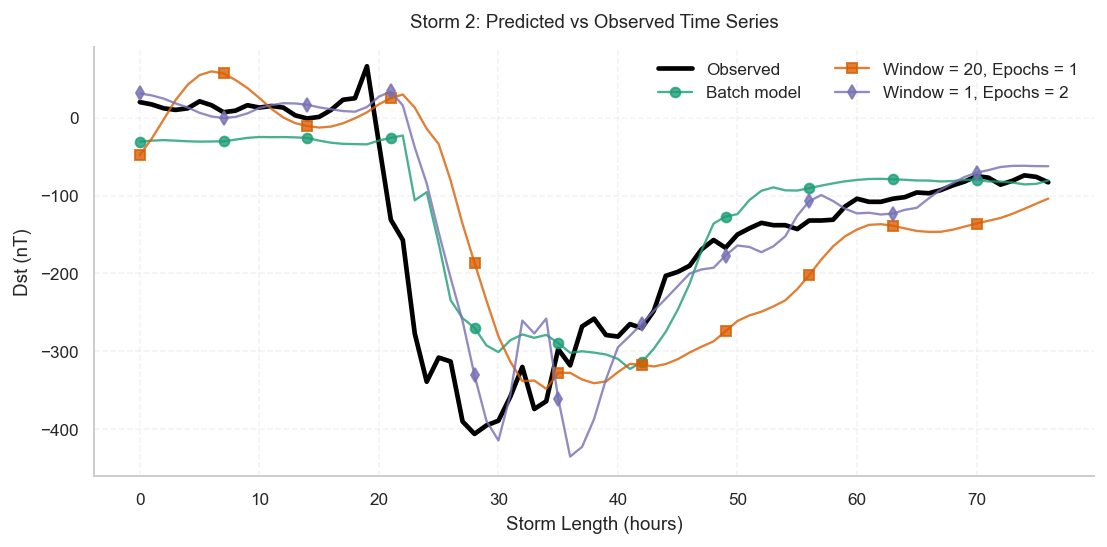

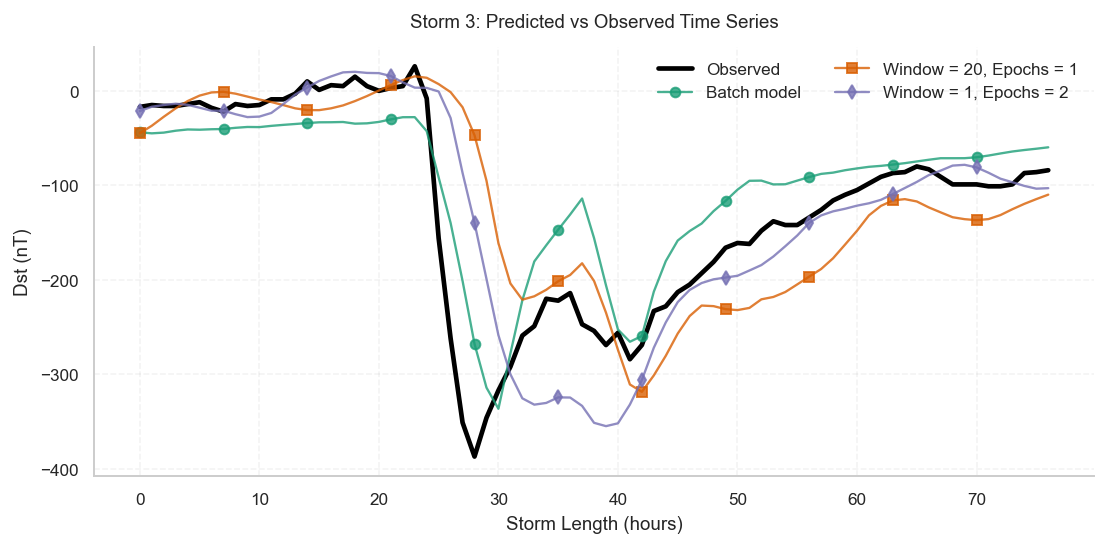

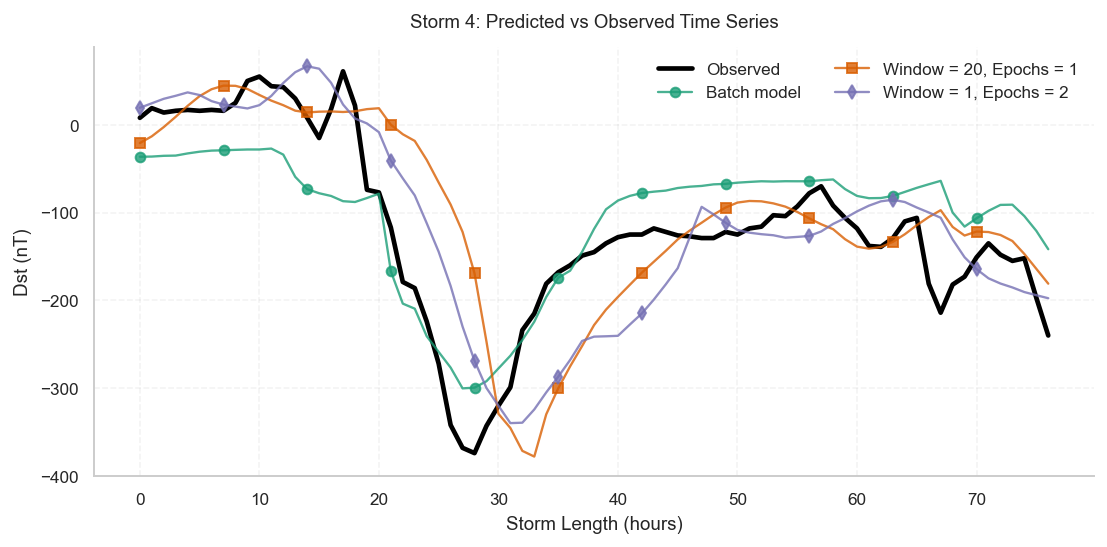

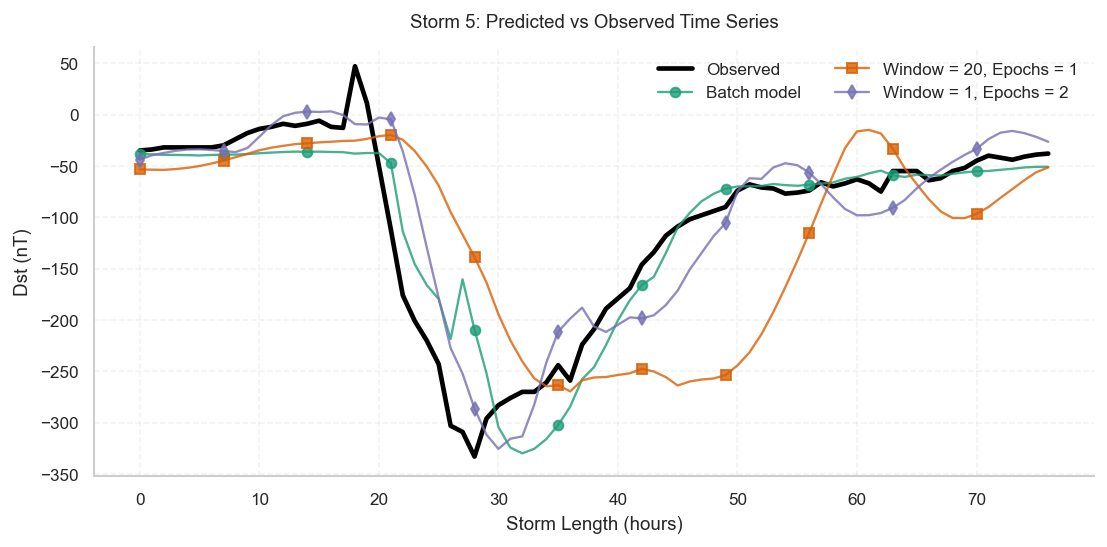

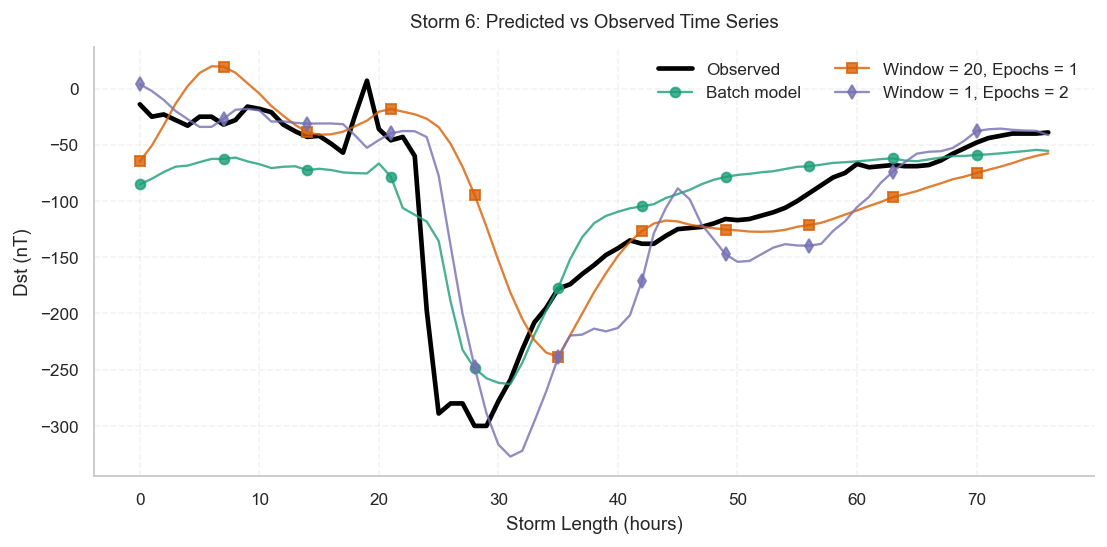

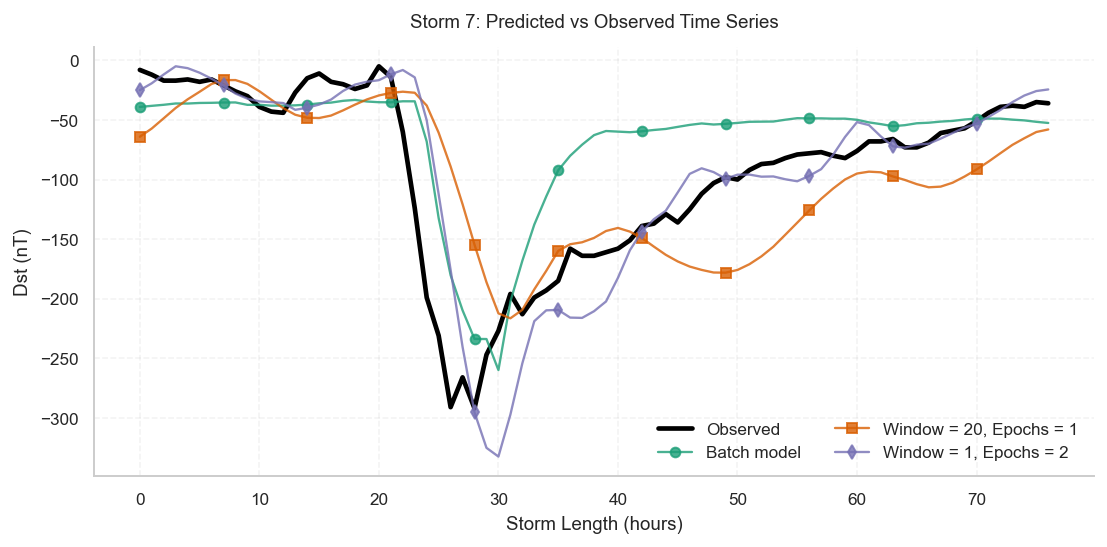

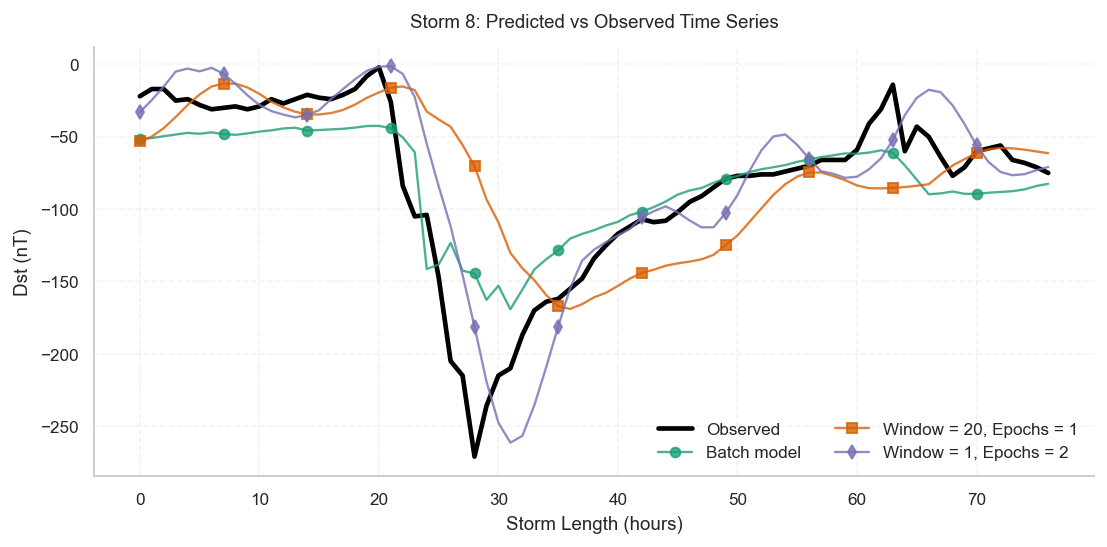

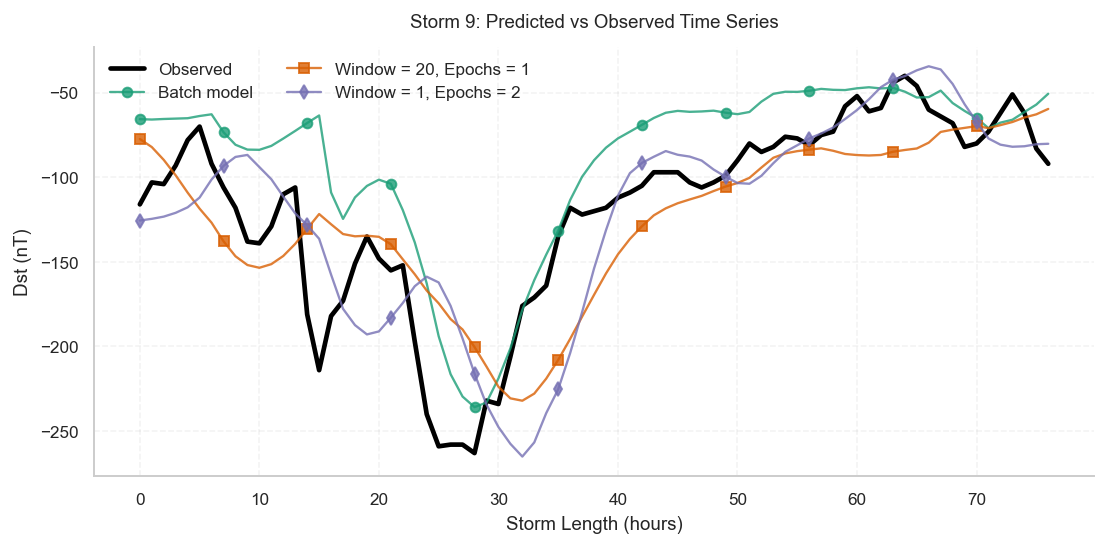

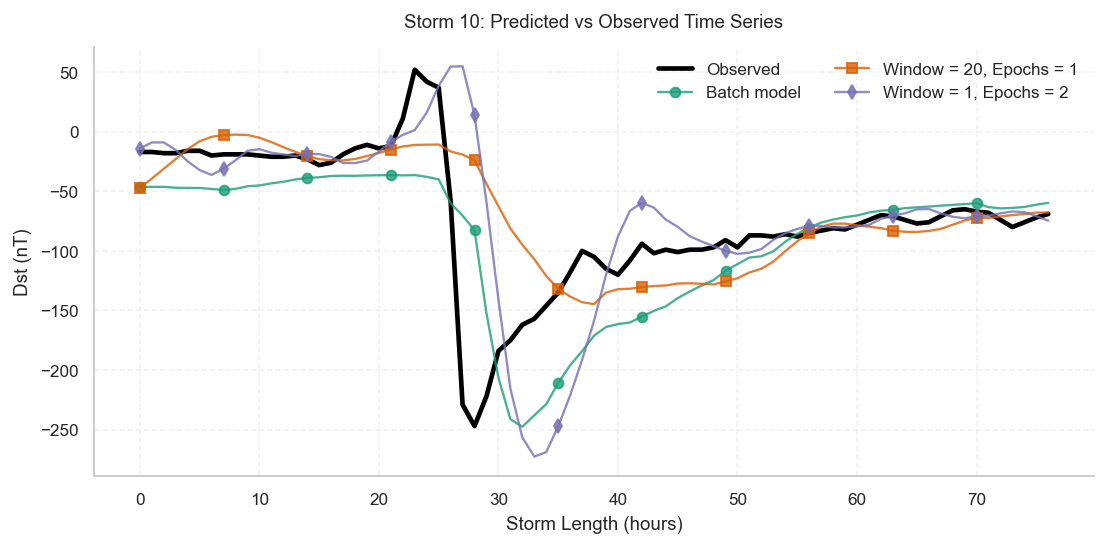

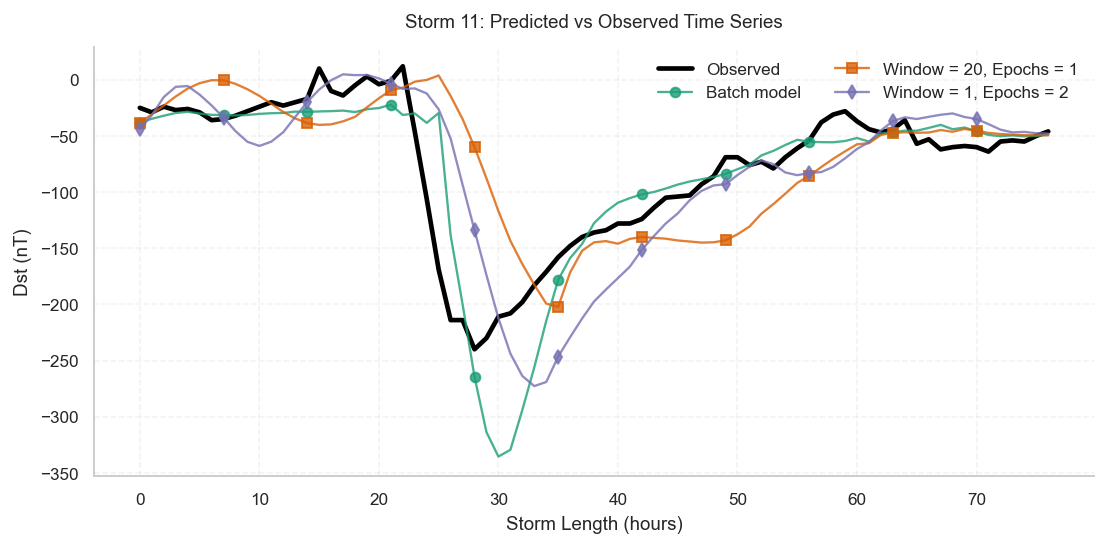

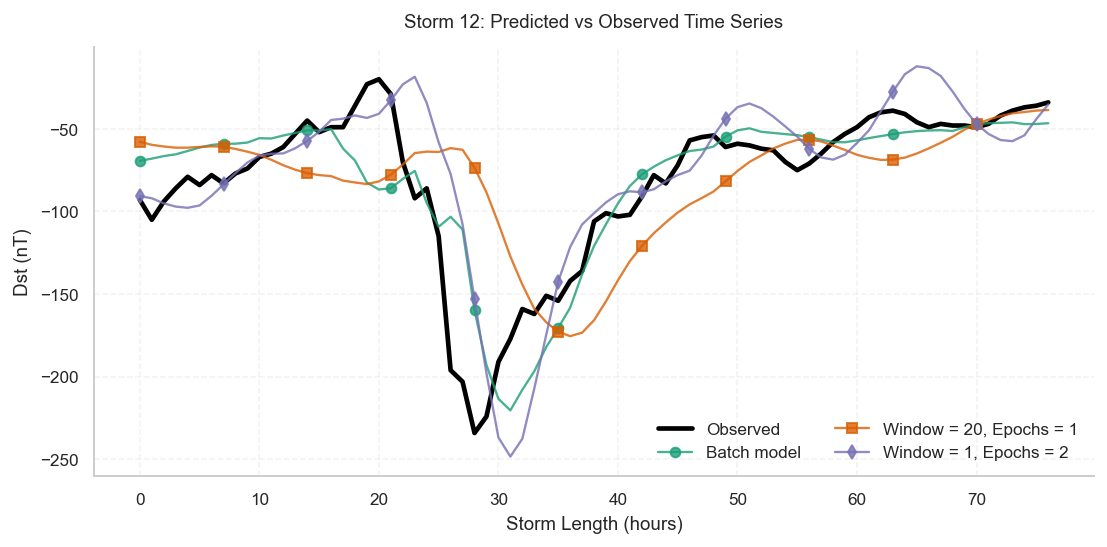

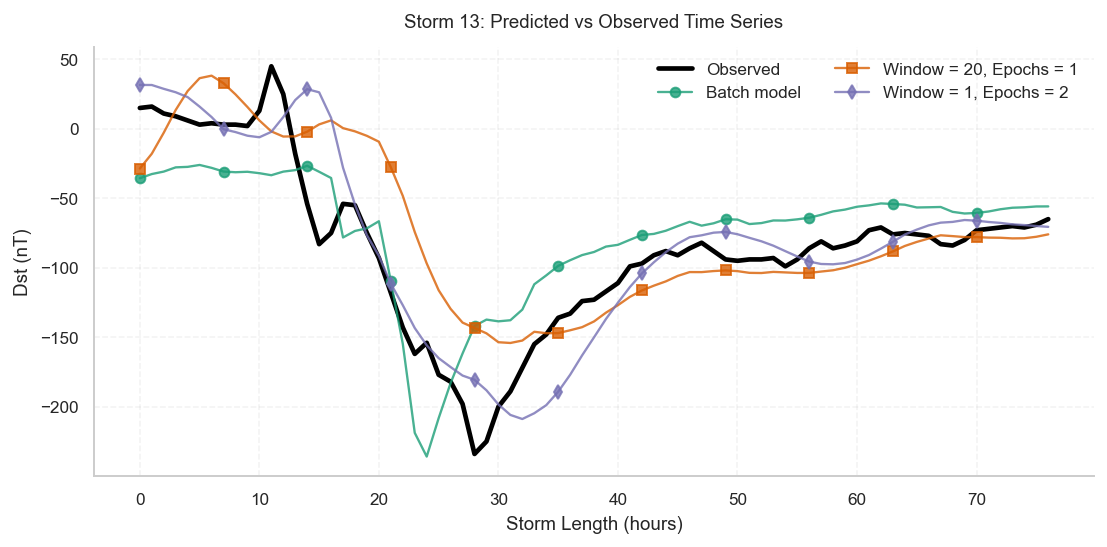

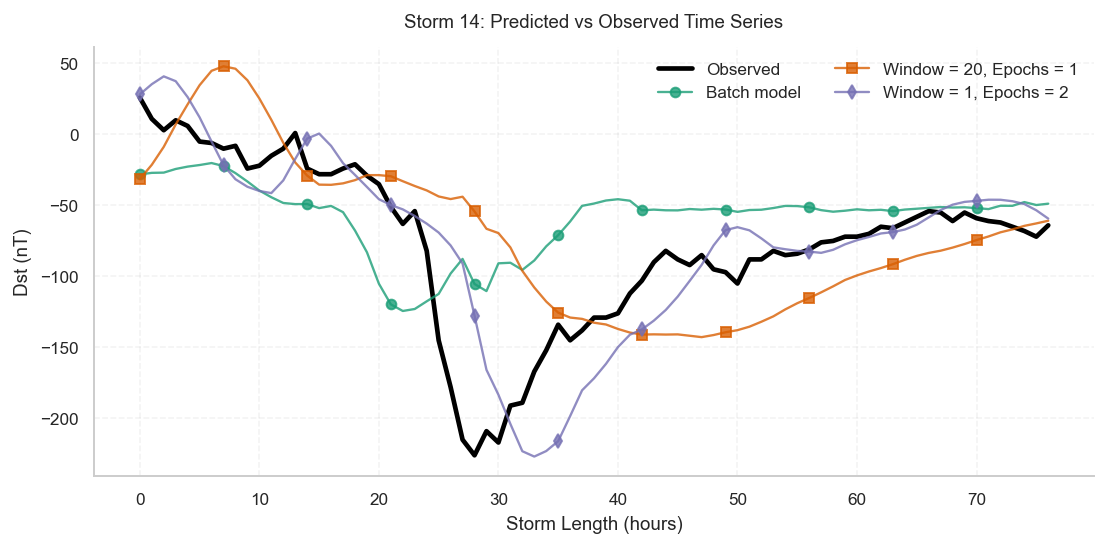

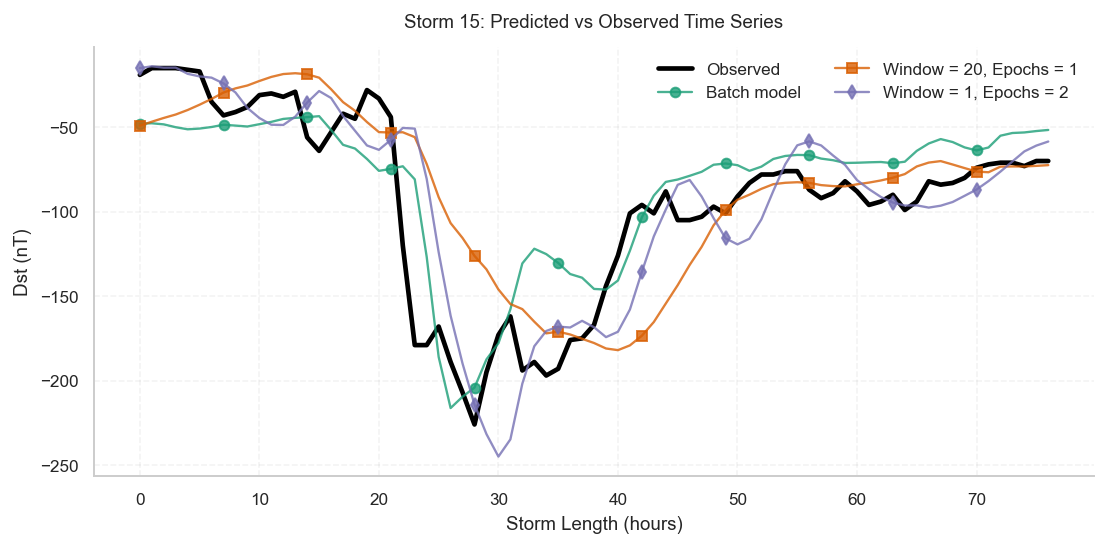

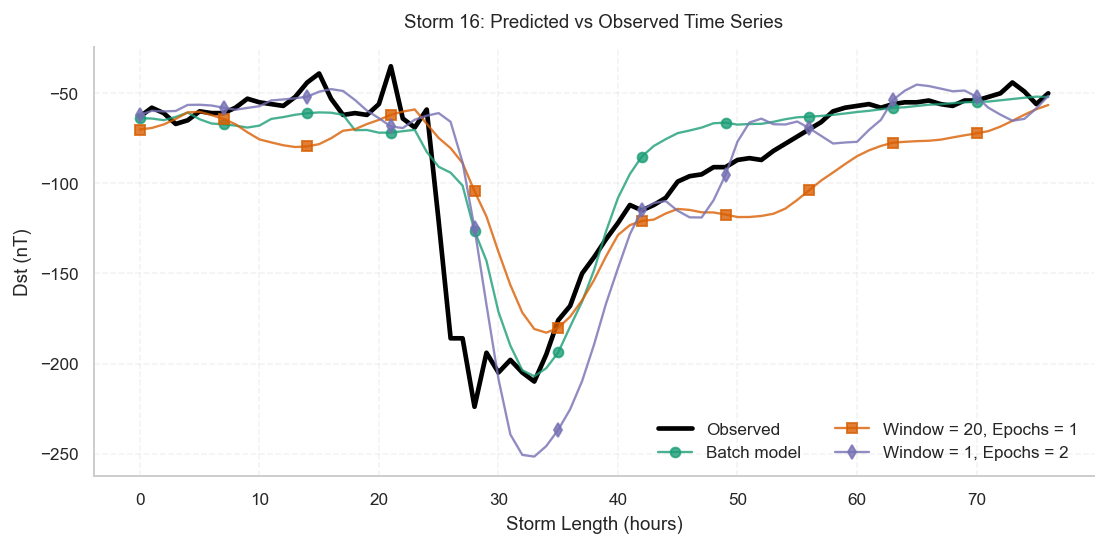

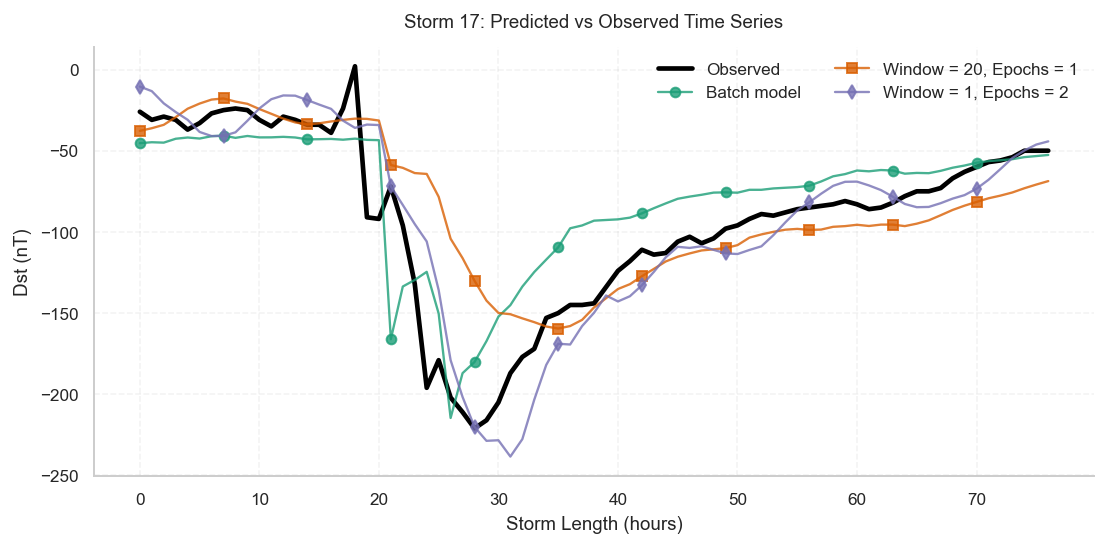

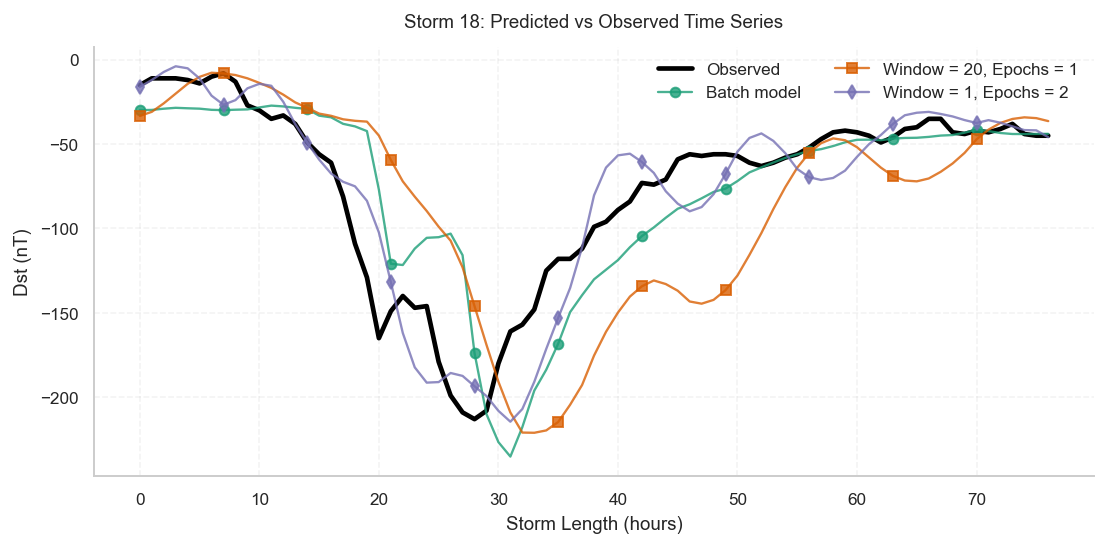

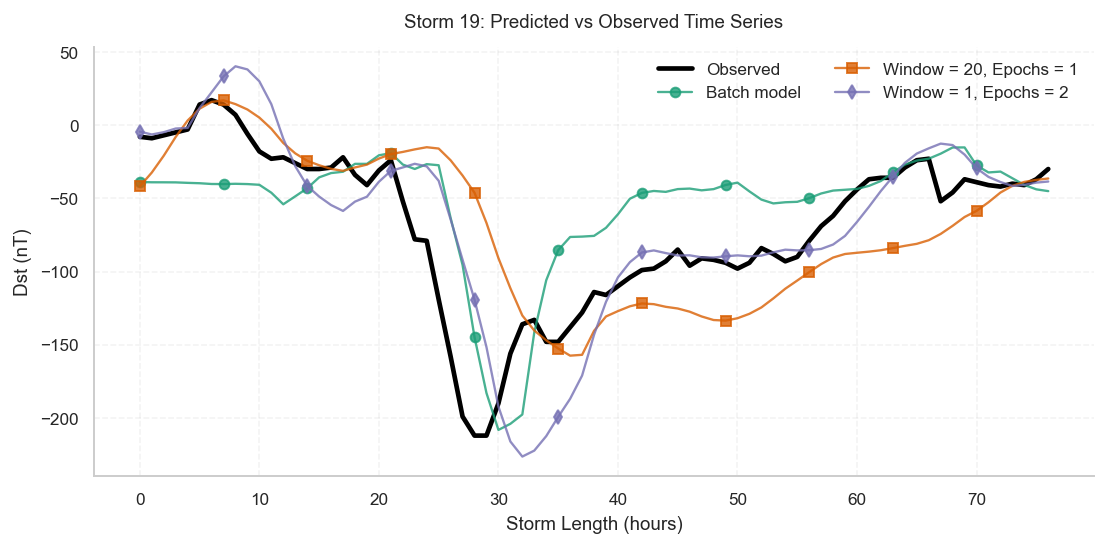

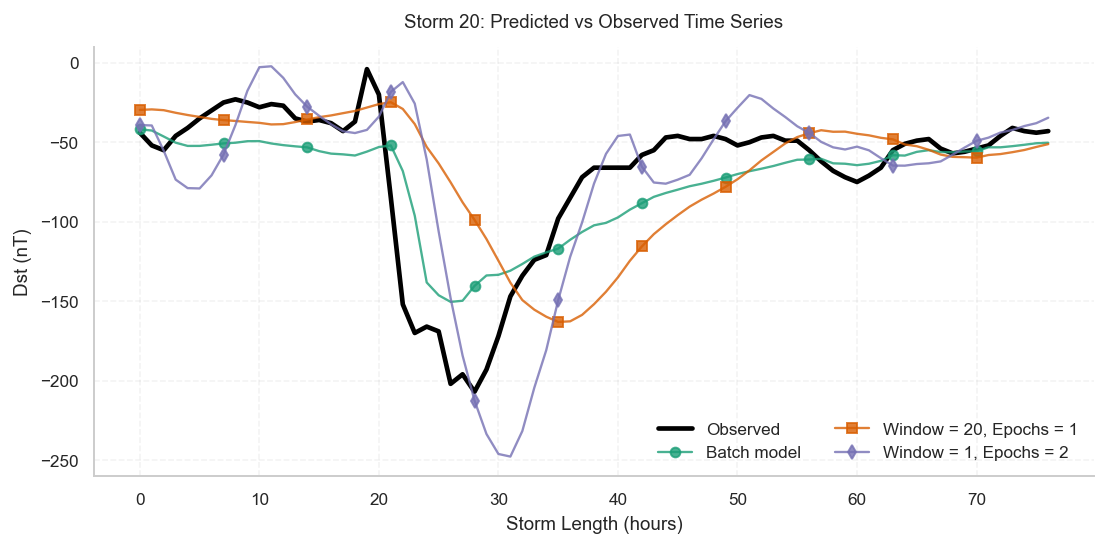

In [6]:
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.dpi"] = 140

for i in range(1, 21):
    y_true_96 = predictions_96.loc[i, 'y_true']
    y_pred_96 = predictions_96.loc[i, 'y_pred']
    y_pred_1_2_5 = predictions_1_2_5.loc[i, 'y_pred']
    batch_predictions = batch_output.loc[i, 'y_pred']

    y_true = np.asarray(y_true_96)
    y_batch = np.asarray(batch_predictions)
    y_96 = np.asarray(y_pred_96)
    y_125 = np.asarray(y_pred_1_2_5)

    y_true = y_true[20:] 
    y_batch = y_batch[20:]
    y_125 = y_125[19:]

    t = np.arange(len(y_96))

    def mae(y, yhat):
        return np.mean(np.abs(y - yhat))

    def rmse(y, yhat):
        return np.sqrt(np.mean((y - yhat) ** 2))

    mae_batch, rmse_batch = mae(y_true, y_batch), rmse(y_true, y_batch)
    mae_96, rmse_96 = mae(y_true, y_96), rmse(y_true, y_96)
    mae_125, rmse_125 = mae(y_true, y_125), rmse(y_true, y_125)

    fig, ax = plt.subplots(figsize = (8, 4))

    ax.plot(t, y_true, color = "black", lw = 2.4, label = "Observed")

    ax.plot(t, y_batch, color = "#1B9E77", lw = 1.2, marker = "o", markersize = 5, markevery = 7, label = "Batch model", alpha = 0.8)
    ax.plot(t, y_96,    color = "#D95F02", lw = 1.2, marker = "s", markersize = 5, markevery = 7, label = "Window = 20, Epochs = 1", alpha = 0.8)
    ax.plot(t, y_125,   color = "#7570B3", lw = 1.2, marker = "d", markersize = 5, markevery = 7, label = "Window = 1, Epochs = 2", alpha = 0.8)

    ax.set_title(f"Storm {i}: Predicted vs Observed Time Series", pad = 10)
    ax.set_xlabel("Storm Length (hours)")
    ax.set_ylabel("Dst (nT)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle = "--", alpha = 0.25)
    ax.legend(frameon = False, loc = "best", ncol = 2)

    fig.tight_layout()
    plt.show()

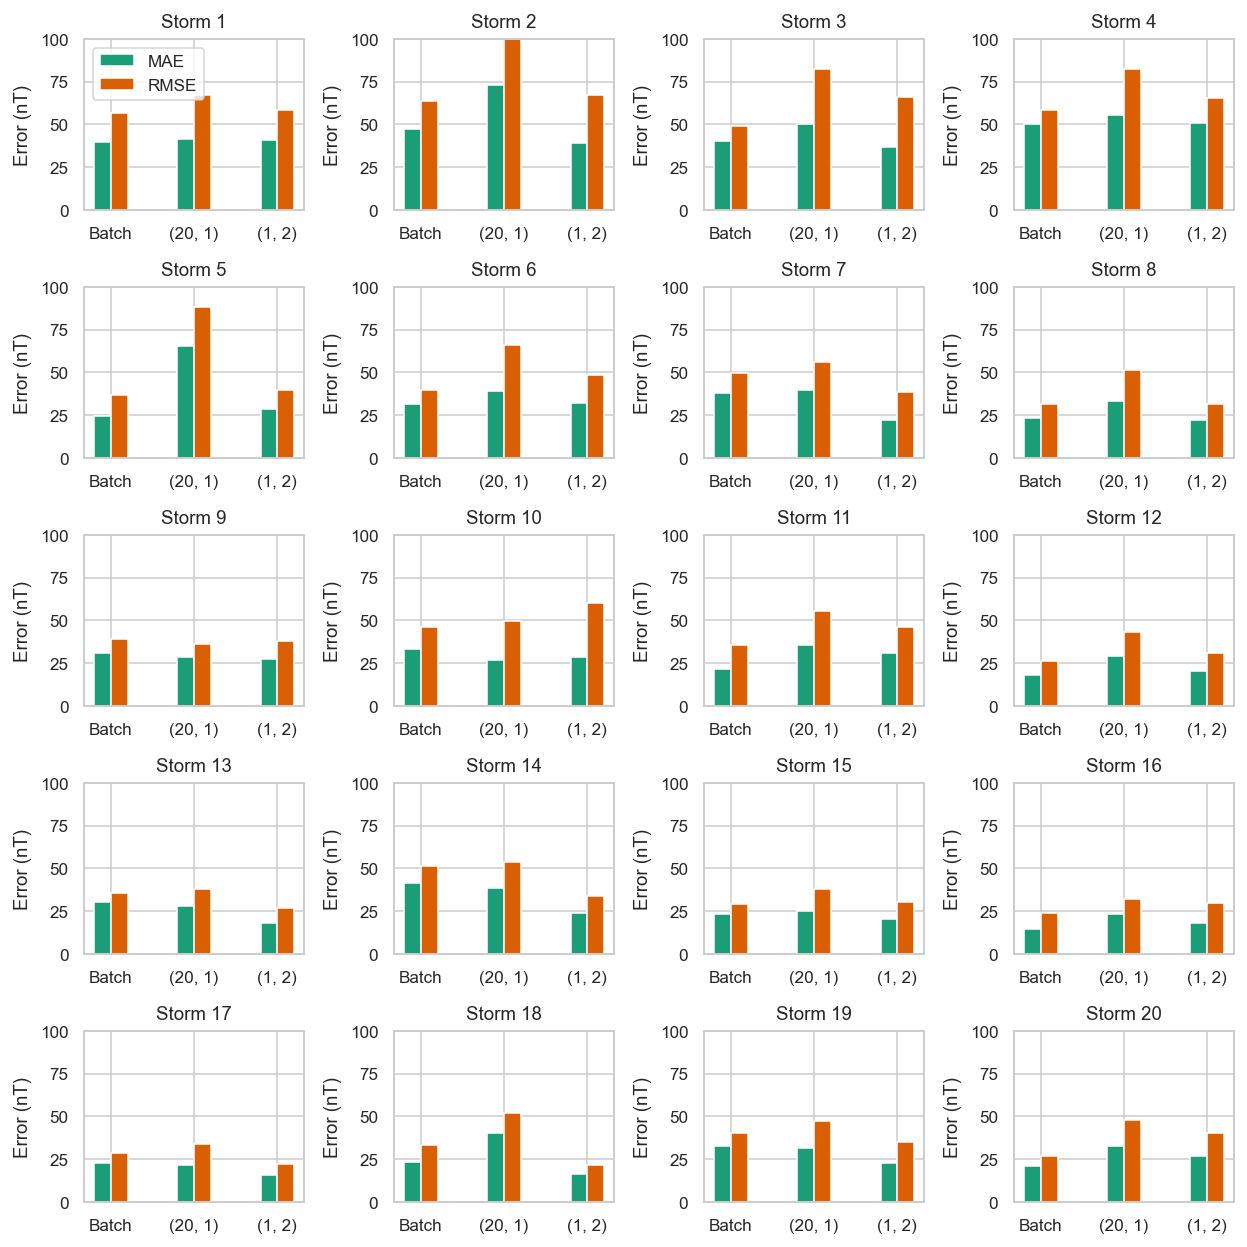

In [7]:
mae_batch_list, rmse_batch_list = [], []
mae_96_list, rmse_96_list = [], []
mae_125_list, rmse_125_list = [], []

for i in range(1, 21):
    y_true_96 = predictions_96.loc[i, 'y_true']
    y_pred_96 = predictions_96.loc[i, 'y_pred']
    y_pred_1_2_5 = predictions_1_2_5.loc[i, 'y_pred']
    batch_predictions = batch_output.loc[i, 'y_pred']

    y_true = np.asarray(y_true_96)
    y_batch = np.asarray(batch_predictions)
    y_96 = np.asarray(y_pred_96)
    y_125 = np.asarray(y_pred_1_2_5)

    y_true = y_true[20:] 
    y_batch = y_batch[20:]
    y_125 = y_125[19:]

    mae_batch_list.append(mae(y_true, y_batch))
    rmse_batch_list.append(rmse(y_true, y_batch))

    mae_96_list.append(mae(y_true, y_96))
    rmse_96_list.append(rmse(y_true, y_96))

    mae_125_list.append(mae(y_true, y_125))
    rmse_125_list.append(rmse(y_true, y_125))

fig, axes = plt.subplots(5, 4, figsize=(9, 9))
axes = axes.flatten()

models = ['Batch', '(20, 1)', '(1, 2)']
x = np.arange(len(models))
width = 0.2

for i in range(20):
    ax = axes[i]

    mae_vals = [mae_batch_list[i], mae_96_list[i], mae_125_list[i]]
    rmse_vals = [rmse_batch_list[i], rmse_96_list[i], rmse_125_list[i]]

    ax.bar(x - width/2, mae_vals, width, label='MAE', color = "#1B9E77")
    ax.bar(x + width/2, rmse_vals, width, label='RMSE', color = "#D95F02")

    ax.set_ylabel('Error (nT)')
    ax.set_ylim(0, 100)
    ax.set_title(f'Storm {i+1}')
    ax.set_xticks(x)
    ax.set_xticklabels(models)

axes[0].legend(loc = 'upper left')

plt.tight_layout()
plt.show()

In [8]:
metrics = pd.DataFrame({
    'Storm': range(1, 21),
    'MAE_Batch': mae_batch_list,
    'RMSE_Batch': rmse_batch_list,
    'MAE (20, 1)': mae_96_list,
    'RMSE (20, 1)': rmse_96_list,
    'MAE (1, 2)': mae_125_list,
    'RMSE (1, 2)': rmse_125_list
})

metrics.set_index('Storm', inplace=True)

metrics = metrics.round(2)
metrics

,MAE_Batch,RMSE_Batch,"MAE (20, 1)","RMSE (20, 1)","MAE (1, 2)","RMSE (1, 2)"
Storm,,,,,,
1,39.89,56.84,41.72,67.24,40.97,58.29
2,47.59,63.55,73.24,100.28,39.26,67.11
3,40.36,49.06,50.26,82.17,36.92,65.88
4,50.47,58.36,55.78,82.65,50.78,65.35
5,24.74,36.99,65.64,88.29,28.54,39.77
6,31.69,39.72,39.06,65.90,32.27,48.71
7,37.95,49.57,39.98,55.92,22.11,38.47
8,23.65,31.28,33.31,51.40,22.37,31.72
9,30.77,39.05,28.87,36.35,27.64,37.87


In [9]:
summary = pd.DataFrame({
    'Model': ['Batch', '(20, 1)', '(1, 2)'],
    'MAE_mean': [
        np.mean(mae_batch_list),
        np.mean(mae_96_list),
        np.mean(mae_125_list)
    ],
    'MAE_std': [
        np.std(mae_batch_list),
        np.std(mae_96_list),
        np.std(mae_125_list)
    ],
    'RMSE_mean': [
        np.mean(rmse_batch_list),
        np.mean(rmse_96_list),
        np.mean(rmse_125_list)
    ],
    'RMSE_std': [
        np.std(rmse_batch_list),
        np.std(rmse_96_list),
        np.std(rmse_125_list)
    ]
})

summary = summary.round(2)
summary

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,Batch,30.46,9.72,40.09,11.29
1,"(20, 1)",38.05,13.44,56.02,18.87
2,"(1, 2)",27.14,9.00,41.48,14.31


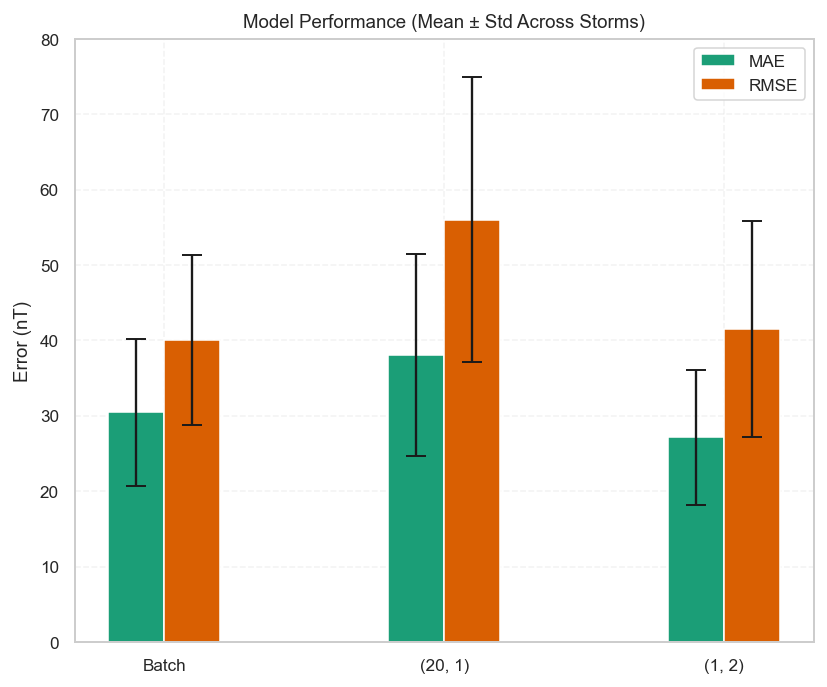

In [10]:
x = np.arange(len(summary['Model']))
width_av = 0.2

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    x - width_av/2,
    summary['MAE_mean'],
    width_av,
    yerr=summary['MAE_std'],
    capsize=5,
    label='MAE',
    color = "#1B9E77"
)

ax.bar(
    x + width_av/2,
    summary['RMSE_mean'],
    width_av,
    yerr=summary['RMSE_std'],
    capsize=5,
    label='RMSE',
    color = "#D95F02"
)

ax.set_xticks(x)
ax.set_xticklabels(summary['Model'])
ax.set_ylabel('Error (nT)')
ax.set_ylim(0, 80)
ax.set_title('Model Performance (Mean ± Std Across Storms)')
ax.grid(linestyle = "--", alpha = 0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import ttest_rel

pairs = [
    ('Batch', mae_batch_list, rmse_batch_list),
    ('96', mae_96_list, rmse_96_list),
    ('1-2-5', mae_125_list, rmse_125_list)
]

results_ttest = []

for i in range(len(pairs)):
    for j in range(i+1, len(pairs)):
        name1, mae1, rmse1 = pairs[i]
        name2, mae2, rmse2 = pairs[j]

        # MAE t-test
        t_mae, p_mae = ttest_rel(mae1, mae2)

        # RMSE t-test
        t_rmse, p_rmse = ttest_rel(rmse1, rmse2)

        results_ttest.append({
            'Comparison': f'{name1} vs {name2}',
            'MAE_t': t_mae,
            'MAE_p': p_mae,
            'RMSE_t': t_rmse,
            'RMSE_p': p_rmse
        })

import pandas as pd
results_ttest = pd.DataFrame(results_ttest)

alpha = 0.05
alpha_bonf = 0.05 / 3

results_ttest['MAE_sig'] = results_ttest['MAE_p'] < alpha_bonf
results_ttest['RMSE_sig'] = results_ttest['RMSE_p'] < alpha_bonf

results_ttest = results_ttest.round(4)
results_ttest

,Comparison,MAE_t,MAE_p,RMSE_t,RMSE_p,MAE_sig,RMSE_sig
0,Batch vs 96,-3.0453,0.0067,-5.2429,0.0000,True,True
1,Batch vs 1-2-5,2.0690,0.0524,-0.6748,0.5079,False,False
2,96 vs 1-2-5,4.7170,0.0002,5.1381,0.0001,True,True


In [12]:
avg_rmse = np.mean(rmse_batch_list)

closest_idx = np.argmin([abs(r - avg_rmse) for r in rmse_batch_list])

print(closest_idx + 1)

19


In [13]:
avg_rmse_all = np.mean([
    np.mean(rmse_batch_list),
    np.mean(rmse_96_list),
    np.mean(rmse_125_list)
])

rmse_mean_per_storm = (
    np.array(rmse_batch_list)
    + np.array(rmse_96_list)
    + np.array(rmse_125_list)
) / 3

typical_idx = np.argmin(np.abs(rmse_mean_per_storm - avg_rmse_all))
print(typical_idx + 1)

worst_idx = np.argmax(rmse_mean_per_storm)
print(worst_idx + 1)

11
2


In [14]:
best_idx = np.argmin(rmse_mean_per_storm)
print(best_idx + 1)

17


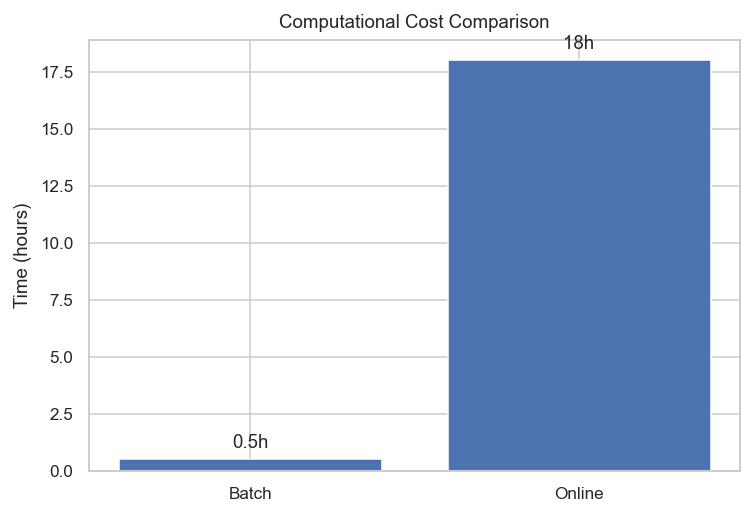

In [16]:
methods = ['Batch', 'Online']
times = [0.5, 18]  # hours

plt.figure(figsize=(6, 4))
plt.bar(methods, times)

plt.ylabel('Time (hours)')
plt.title('Computational Cost Comparison')

# annotate values
for i, v in enumerate(times):
    plt.text(i, v + 0.5, f"{v}h", ha='center')

plt.show()

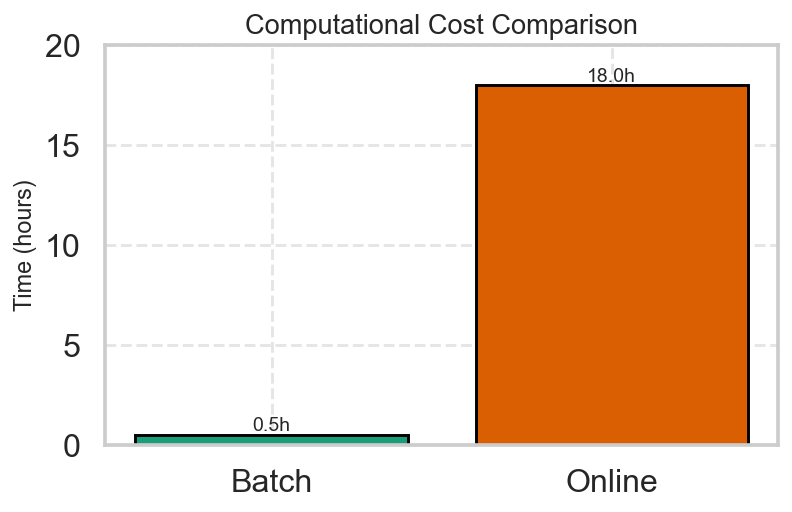

In [22]:
methods = ['Batch', 'Online']
times = [0.5, 18]

colors = ['#1B9E77', '#D95F02']

plt.figure(figsize=(6,4))

bars = plt.bar(methods, times, color=colors, edgecolor='black')

plt.ylabel('Time (hours)', fontsize=12)
plt.title('Computational Cost Comparison', fontsize=14)
plt.ylim(0, 20)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height}h',
             ha='center', va='bottom', fontsize=10)

plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()